# KDD Data Analysis and Attack Classification using Machine Learning & Neural Networks
This notebook covers data preprocessing, feature engineering, and training multiple ML models to classify attacks using the KDD dataset.

In [ ]:

import pandas as pd  # Importing pandas for data handling
import numpy as np  # Importing numpy for numerical operations
import seaborn as sns  # Importing seaborn for visualization
import matplotlib.pyplot as plt  # Importing matplotlib for plotting graphs
from sklearn.model_selection import train_test_split  # Splitting dataset into train and test
from sklearn.preprocessing import StandardScaler, LabelEncoder  # Encoding categorical variables and scaling data
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier  # Importing classification models
from sklearn.svm import SVC  # Importing Support Vector Classifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix  # Evaluation metrics
import tensorflow as tf  # TensorFlow for deep learning
from tensorflow import keras  # Keras API for building models
from tensorflow.keras.models import Sequential  # Sequential model type
from tensorflow.keras.layers import Dense, Dropout  # Neural network layers


## Load the KDD dataset from URL

In [ ]:









from sklearn.datasets import fetch_kddcup99
import pandas as pd

data = fetch_kddcup99(percent10=True, as_frame=True)

df = data.frame
df.columns = ["duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
              "num_failed_logins", "logged_in", "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations", "num_shells",
              "num_access_files", "num_outbound_cmds", "is_host_login", "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
              "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
              "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
              "dst_host_srv_serror_rate", "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label"]

print(df.head())

  duration protocol_type  service   flag src_bytes dst_bytes land  \
0        0        b'tcp'  b'http'  b'SF'       181      5450    0   
1        0        b'tcp'  b'http'  b'SF'       239       486    0   
2        0        b'tcp'  b'http'  b'SF'       235      1337    0   
3        0        b'tcp'  b'http'  b'SF'       219      1337    0   
4        0        b'tcp'  b'http'  b'SF'       217      2032    0   

  wrong_fragment urgent hot  ... dst_host_srv_count dst_host_same_srv_rate  \
0              0      0   0  ...                  9                    1.0   
1              0      0   0  ...                 19                    1.0   
2              0      0   0  ...                 29                    1.0   
3              0      0   0  ...                 39                    1.0   
4              0      0   0  ...                 49                    1.0   

  dst_host_diff_srv_rate dst_host_same_src_port_rate  \
0                    0.0                        0.11   
1   

In [ ]:
# sample 5000 rows to make training faster

# Sample 5000 rows from the DataFrame
df = df.sample(n=5000, random_state=42)  # Use random_state for reproducibility

# Now df_sampled contains your sampled data
df.shape


## Data Preprocessing & Feature Engineering

In [ ]:

# Encoding categorical variables into numeric form
encoder = LabelEncoder()
categorical_columns = ['protocol_type', 'service', 'flag']
for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

# Convert labels into binary classification (attack or normal)
df['label'] = df['label'].apply(lambda x: 'normal' if x == 'normal.' else 'attack')
df['label'] = encoder.fit_transform(df['label'])

# Feature Engineering: Creating new features
df['byte_ratio'] = df['src_bytes'] / (df['dst_bytes'] + 1)
df['total_count'] = df['count'] + df['srv_count']
df['error_rate'] = (df['serror_rate'] + df['rerror_rate']) / 2

df.head()


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,byte_ratio,total_count,error_rate
0,0,1,22,9,181,5450,0,0,0,0,...,0.11,0.0,0.0,0.0,0.0,0.0,1,0.033205,16,0.0
1,0,1,22,9,239,486,0,0,0,0,...,0.05,0.0,0.0,0.0,0.0,0.0,1,0.490760,16,0.0
2,0,1,22,9,235,1337,0,0,0,0,...,0.03,0.0,0.0,0.0,0.0,0.0,1,0.175635,16,0.0
3,0,1,22,9,219,1337,0,0,0,0,...,0.03,0.0,0.0,0.0,0.0,0.0,1,0.163677,12,0.0
4,0,1,22,9,217,2032,0,0,0,0,...,0.02,0.0,0.0,0.0,0.0,0.0,1,0.106739,12,0.0


## Splitting Data into Training and Testing Sets

In [ ]:

X = df.drop('label', axis=1)
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## Training Machine Learning Models
Random Forest Classifiers:
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

Gradient Boosting Classifier:
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html

Support Vector Classifier:
https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#

In [ ]:

# RandomForest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# Gradient Boosting Classifier
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

# Support Vector Machine (SVM)
svm = SVC(kernel='linear', probability=True)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


Random Forest Accuracy: 0.9997469763675927
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     79452
           1       1.00      1.00      1.00     19353

    accuracy                           1.00     98805
   macro avg       1.00      1.00      1.00     98805
weighted avg       1.00      1.00      1.00     98805

Gradient Boosting Accuracy: 0.9993016547745559
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     79452
           1       1.00      1.00      1.00     19353

    accuracy                           1.00     98805
   macro avg       1.00      1.00      1.00     98805
weighted avg       1.00      1.00      1.00     98805

SVM Accuracy: 0.9973584332776682
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     79452
           1       0.99      1.00      0.99     19353

    accuracy                           1.00     98805
   ma

## Building a Neural Network Classifier

In [ ]:

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))


NameError: name 'Sequential' is not defined

## Evaluating Neural Network Performance

In [ ]:

y_pred_nn = (model.predict(X_test) > 0.5).astype("int32")
print("Neural Network Accuracy:", accuracy_score(y_test, y_pred_nn))
print(classification_report(y_test, y_pred_nn))

# Plot training history
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Neural Network Training History')
plt.show()


Based on the above code, write your own code to develop other ML or Neural network algorithms from list below.

Machine Learning Algorithms
**bold text**
Decision Tree Classifier:  https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

K-Nearest Neighbors (KNN):  https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

Logistic Regression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

Naive Bayes Classifier: https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html


**Deep Learning Models**
Long Short-Term Memory (LSTM): https://keras.io/api/layers/recurrent_layers/lstm/

Convolutional Neural Networks (CNN): https://keras.io/api/layers/convolution_layers/convolution1d/

Transformers (Hugging Face Transformers)

**Important: Lab-Logbbok requirement**

Provide a bar graph comparing accuracy, precicion, recall, and f-score for various AI models



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import fetch_kddcup99
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, LSTM, Conv1D, MaxPooling1D, Flatten,
    MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D
)

In [ ]:
data = fetch_kddcup99(percent10=True, as_frame=True)
df = data.frame.copy()


In [ ]:
df.columns = list(data.feature_names) + ["label"]
def decode_value(x):
    return x.decode("utf-8") if isinstance(x, (bytes, bytearray)) else x

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].apply(decode_value)

df = df.sample(n=5000, random_state=42).reset_index(drop=True)

In [ ]:
categorical_columns = ["protocol_type", "service", "flag"]

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

In [ ]:
df["label"] = df["label"].apply(lambda x: "normal" if x == "normal." else "attack")
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["label"])

df["byte_ratio"] = df["src_bytes"] / (df["dst_bytes"] + 1)
df["total_count"] = df["count"] + df["srv_count"]
df["error_rate"] = (df["serror_rate"] + df["rerror_rate"]) / 2

In [ ]:
X_train_dl = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_dl = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)


In [ ]:
performance_results = []

def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    performance_results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

    print(f"\n{name}")
    print("Accuracy:", acc)
    print(classification_report(y_true, y_pred, zero_division=0))

def evaluate_dl_model(name, model, X_test_data, y_true):
    y_prob = model.predict(X_test_data, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)
    evaluate_model(name, y_true, y_pred)

In [ ]:
# Decision Tree
dt = DecisionTreeClassifier(max_depth=12, random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)
evaluate_model("Decision Tree", y_test, y_pred_dt)

# K-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
evaluate_model("KNN", y_test, y_pred_knn)

# Logistic Regression
lr = LogisticRegression(max_iter=2000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
evaluate_model("Logistic Regression", y_test, y_pred_lr)

# Naive Bayes
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
y_pred_nb = nb.predict(X_test_scaled)
evaluate_model("Naive Bayes", y_test, y_pred_nb)


Decision Tree
Accuracy: 0.996
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       805
           1       0.99      0.98      0.99       195

    accuracy                           1.00      1000
   macro avg       1.00      0.99      0.99      1000
weighted avg       1.00      1.00      1.00      1000


KNN
Accuracy: 0.998
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       805
           1       0.99      1.00      0.99       195

    accuracy                           1.00      1000
   macro avg       0.99      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


Logistic Regression
Accuracy: 0.997
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       805
           1       0.99      0.99      0.99       195

    accuracy                           1.00      1000
   macro avg       1.00      0.99      

In [ ]:
# LSTM
lstm_classifier = Sequential([
    Input(shape=(X_train_dl.shape[1], 1)),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dense(16, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

lstm_classifier.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
lstm_classifier.fit(
    X_train_dl, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

evaluate_dl_model("LSTM", lstm_classifier, X_test_dl, y_test)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.9284 - loss: 0.3943 - val_accuracy: 0.9700 - val_loss: 0.1264
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9766 - loss: 0.1290 - val_accuracy: 0.9787 - val_loss: 0.0854
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.9775 - loss: 0.0940 - val_accuracy: 0.9787 - val_loss: 0.0616
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.9825 - loss: 0.0653 - val_accuracy: 0.9675 - val_loss: 0.0843
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9825 - loss: 0.0614 - val_accuracy: 0.9737 - val_loss: 0.0464
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9856 - loss: 0.0507 - val_accuracy: 0.9875 - val_loss: 0.0354
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9862 - loss: 0.0515 - val_accuracy: 0.9862 - val_loss: 0.0460
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.9781 - loss: 0.0802 - val_accuracy: 0.9762 - v

In [ ]:

# CNN
cnn_model = Sequential([
    Input(shape=(X_train_dl.shape[1], 1)),
    Conv1D(128, kernel_size=3, activation="relu"),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),
    Conv1D(64, kernel_size=3, activation="relu"),
    Flatten(),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

cnn_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
cnn_model.fit(
    X_train_dl, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

evaluate_dl_model("CNN", cnn_model, X_test_dl, y_test)


Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9438 - loss: 0.1863 - val_accuracy: 0.9875 - val_loss: 0.0427
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9919 - loss: 0.0384 - val_accuracy: 0.9900 - val_loss: 0.0407
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9947 - loss: 0.0234 - val_accuracy: 0.9925 - val_loss: 0.0200
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9956 - loss: 0.0249 - val_accuracy: 0.9937 - val_loss: 0.0185
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9966 - loss: 0.0181 - val_accuracy: 0.9900 - val_loss: 0.0413
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9969 - loss: 0.0172 - val_accuracy: 0.9950 - val_loss: 0.0176
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9969 - loss: 0.0140 - val_accuracy: 0.9912 - val_loss: 0.0297
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9966 - loss: 0.0119 - val_accuracy: 0.9925 - v

In [ ]:
def transformer_block(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.2):
    attn_output = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=head_size,
        dropout=dropout
    )(x, x)

    x = LayerNormalization(epsilon=1e-6)(x + attn_output)

    ffn = Dense(ff_dim, activation="relu")(x)
    ffn = Dropout(0.2)(ffn)
    ffn = Dense(int(x.shape[-1]))(ffn)

    return LayerNormalization(epsilon=1e-6)(x + ffn)

inputs = Input(shape=(X_train_dl.shape[1], 1))
x = Dense(64)(inputs)
x = transformer_block(x)
x = transformer_block(x)
x = GlobalAveragePooling1D()(x)
x = Dropout(0.3)(x)
outputs = Dense(1, activation="sigmoid")(x)

transformer_model = Model(inputs, outputs)
transformer_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
transformer_model.fit(
    X_train_dl, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

evaluate_dl_model("Transformer", transformer_model, X_test_dl, y_test)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 214ms/step - accuracy: 0.9219 - loss: 0.2339 - val_accuracy: 0.9538 - val_loss: 0.1300
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 196ms/step - accuracy: 0.9525 - loss: 0.1277 - val_accuracy: 0.9425 - val_loss: 0.1388
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 187ms/step - accuracy: 0.9525 - loss: 0.1172 - val_accuracy: 0.9413 - val_loss: 0.1109
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 208ms/step - accuracy: 0.9581 - loss: 0.1065 - val_accuracy: 0.9675 - val_loss: 0.0873
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 208ms/step - accuracy: 0.9628 - loss: 0.0953 - val_accuracy: 0.9588 - val_loss: 0.1052
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 180ms/step - accuracy: 0.9700 - loss: 0.0836 - val_accuracy: 0.9550 - val_loss: 0.1226
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 206ms/step - accuracy: 0.9719 - loss: 0.0741 - val_accuracy: 0.9787 - val_loss: 0.0593
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 206ms/step - accuracy: 0.9706 - loss: 0.0762 - val_accu

In [ ]:
results_df = pd.DataFrame(performance_results)
print("\nFinal Results:")
print(results_df)


Final Results:
                 Model  Accuracy  Precision    Recall  F1-Score
0        Decision Tree     0.996   0.994819  0.984615  0.989691
1                  KNN     0.998   0.989848  1.000000  0.994898
2  Logistic Regression     0.997   0.994845  0.989744  0.992288
3          Naive Bayes     0.994   0.989637  0.979487  0.984536
4                 LSTM     0.992   0.979487  0.979487  0.979487
5                  CNN     0.992   0.994709  0.964103  0.979167
6          Transformer     0.974   0.994152  0.871795  0.928962


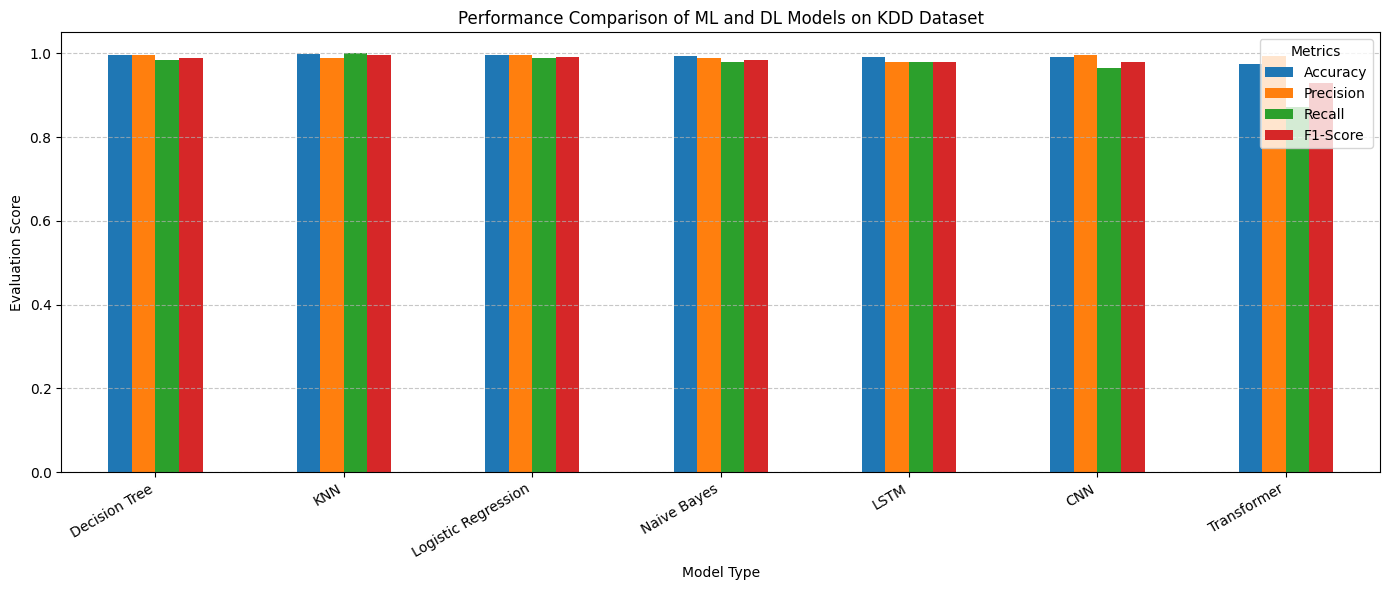

In [ ]:
# Visual comparison of model performance metrics
plot_df = results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]]

ax = plot_df.plot(kind="bar", figsize=(14, 6))
plt.title("Performance Comparison of ML and DL Models on KDD Dataset")
plt.xlabel("Model Type")
plt.ylabel("Evaluation Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha="right")
plt.legend(title="Metrics")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()